## 0. Tiền xử lý dữ liệu

Import các thư viện cần thiết để xử lý dữ liệu

In [ ]:
import os
import gc
import dask
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import linregress

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
FOLDER_PATH = "../data/merged"

Gọi hàm con để xử lý dữ liệu thô được lấy từ ERA5

In [2]:
def preprocess(ds):
    if 'valid_time' in ds.coords: 
        ds = ds.rename({'valid_time': 'time'})
    if 'expver' in ds.dims: 
        ds = ds.mean(dim='expver')
    return ds.sortby('time')

Dữ liệu gốc về các tầng đất bao gồm:

| Tầng   | Độ sâu        | Đặc điểm                                          |
| ------- | ------------ | -------------------------------------------------- |
| Level 1 | 0 – 7 cm     | Phản ứng với mưa trong vài giờ. Rất dễ bốc hơi |
| Level 2 | 7 – 28 cm    | Phản ứng trong vài ngày. Đưa ra các tín hiệu rất mượt mà |
| Level 3 | 28 – 100 cm  | Phản ứng trong vài tuần. Là vùng gốc của nhiều cây trồng |
| Level 4 | 100 – 289 cm | Phản ứng trong nhiều tháng. Là nơi phát đi tín hiệu cấp nước ngầm |

Xử lý dữ liệu để tạo ra các biến khác nhau. Trong số này:
- df_daily: Chỉ số độ ẩm các tầng đất theo ngày
- df_monthly: Chỉ số độ ẩm các tầng đất theo tháng
- df_clim: Chỉ số độ ẩm các tầng đất trong từng tháng
- df_anom: Chỉ số độ ẩm các tầng đất dị thường theo ngày

Quy luật vật lý ở đây ngược lại so với nhiệt độ của đất:
- Về mặt nhiệt độ, tín hiệu lan truyền xuống dựa vào sóng nhiệt và khi đến lớp sâu hơn ở dưới, nó có một độ trễ nhất định.
- Về mặt độ ẩm, tín hiệu lan truyền xuống dưới nhưng đã bị hấp thụ bởi rễ cây và thoát nước trên đường đi, thế nên lớp sâu hơn không chỉ trễ hơn lớp ở trên, mà tín hiệu cũng đã bị biến đổi.

In [3]:
def get_soil_moisture_data_optimized(folder_path, soil_paths):
    # Open each file separately
    datasets = [preprocess(xr.open_dataset(os.path.join(folder_path, p))) for p in soil_paths]
    
    # One lazy array per file
    lazy = [ds[list(ds.data_vars)[0]].mean(dim=["latitude", "longitude"]).resample(time="1D").mean() for ds in datasets]

    # Compute all files in parallel in one shot
    computed = dask.compute(*lazy)  

    for ds in datasets:
        ds.close()

    # Merge into one Dataset
    sw_vars = [list(ds.data_vars)[0] for ds in datasets]
    daily_soil = xr.Dataset({v: arr for v, arr in zip(sw_vars, computed)})

    # All downstream ops are now pure in-memory, near-instant
    monthly_soil = daily_soil.resample(time="1ME").mean()
    clim_soil = daily_soil.groupby("time.month").mean("time")
    anom_soil = daily_soil.groupby("time.month") - clim_soil

    df_daily = daily_soil.to_dataframe()
    df_monthly = monthly_soil.to_dataframe()
    df_clim = clim_soil.to_dataframe()
    df_anom = anom_soil.to_dataframe()

    gc.collect()

    return df_daily, df_monthly, df_clim, df_anom

In [4]:
soil_paths = [f'volumetric_soil_water_layer_{i}_merged.nc' for i in range(1, 5)]
df_daily, df_monthly, df_clim, df_anom = get_soil_moisture_data_optimized(FOLDER_PATH, soil_paths)

In [5]:
df_daily = df_daily.drop(columns=['number']).reset_index()
df_daily.head()

,time,swvl1,swvl2,swvl3,swvl4
0,1980-01-01,0.176111,0.192965,0.227972,0.287575
1,1980-01-02,0.174253,0.192041,0.227359,0.287300
2,1980-01-03,0.172704,0.191269,0.226817,0.287023
3,1980-01-04,0.173270,0.190580,0.226308,0.286753
4,1980-01-05,0.175961,0.190762,0.225898,0.286500


In [6]:
df_monthly = df_monthly.drop(columns=['number']).reset_index()
df_monthly.head()

,time,swvl1,swvl2,swvl3,swvl4
0,1980-01-31,0.177189,0.191753,0.224949,0.283906
1,1980-02-29,0.185679,0.191733,0.219893,0.277347
2,1980-03-31,0.192763,0.190761,0.212626,0.270913
3,1980-04-30,0.221215,0.202094,0.199307,0.264532
4,1980-05-31,0.279800,0.261152,0.212385,0.260375


In [7]:
df_clim = df_clim.drop(columns=['number']).reset_index()
df_clim.head()

,month,swvl1,swvl2,swvl3,swvl4
0,1,0.194555,0.206188,0.234086,0.288159
1,2,0.190127,0.198756,0.225555,0.281299
2,3,0.200709,0.199296,0.218227,0.274699
3,4,0.230366,0.216120,0.212594,0.268764
4,5,0.274026,0.257663,0.223211,0.265368


In [8]:
df_anom = df_anom.drop(columns=['number']).reset_index()
df_anom.head()

,time,month,swvl1,swvl2,swvl3,swvl4
0,1980-01-01,1,-0.018445,-0.013224,-0.006114,-0.000584
1,1980-01-02,1,-0.020302,-0.014147,-0.006727,-0.000859
2,1980-01-03,1,-0.021851,-0.014919,-0.007269,-0.001136
3,1980-01-04,1,-0.021285,-0.015608,-0.007778,-0.001406
4,1980-01-05,1,-0.018594,-0.015426,-0.008188,-0.001659


## 1. Chỉ số độ ẩm của đất trên từng tầng qua 45 năm

So sánh độ ẩm của từng tầng đất, tính trung bình mỗi tháng trong suốt 45 năm. Nhìn theo chiều dọc để có thể thấy được sự khác biệt về độ ẩm giữa các tầng đất, đặc biệt là giữa tầng bề mặt và các tầng sâu hơn. Ví dụ: Khi mùa mưa đến, tầng bề mặt sẽ ẩm ướt ngay lập tức, nhưng tầng thứ 4 sẽ không thấy gì cho đến hàng tuần sau đấy.

Vì trường hợp như trên xảy ra, nên sau đó cả 4 tầng sẽ hội tụ vào một mức tối thiểu chung đúng vào dịp khô nhất của mùa khô. Điểm hội tụ đó chính là lượng ẩm còn lại mà hệ thống không bao giờ thoát hết — một đại lượng có ý nghĩa sinh thái cực kỳ quan trọng.

In [9]:
depths     = [0.035, 0.175, 0.640, 1.945]   # layer midpoints in metres
depth_lbls = ["7 cm", "28 cm", "100 cm", "289 cm"]
thicknesses = np.array([0.07, 0.21, 0.72, 1.89])
sw_vars = ['swvl1', 'swvl2', 'swvl3', 'swvl4']

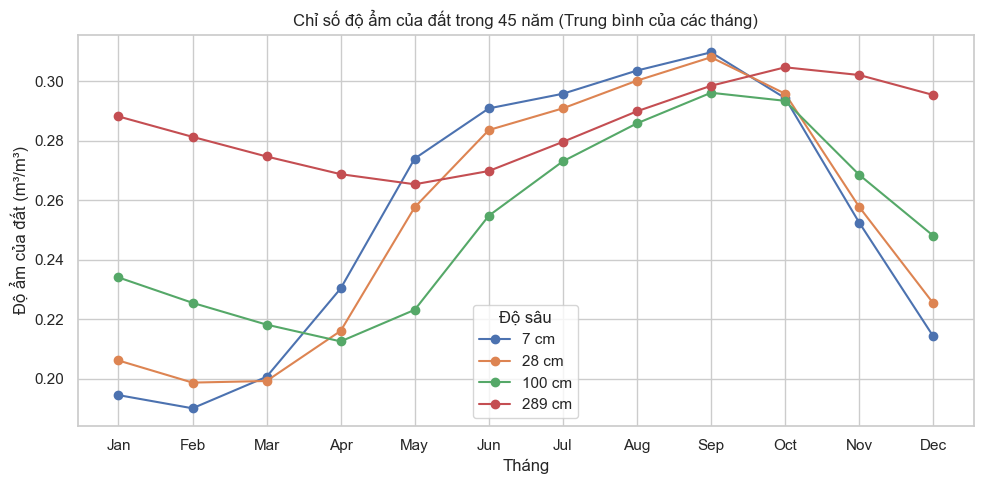

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

for v, depth_lbl in zip(sw_vars, depth_lbls):
    ax.plot(range(1, 13), df_clim[v].values, marker="o", label=depth_lbl)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_xlabel("Tháng")
ax.set_ylabel("Độ ẩm của đất (m³/m³)")
ax.set_title("Chỉ số độ ẩm của đất trong 45 năm (Trung bình của các tháng)")
ax.legend(title="Độ sâu")
plt.tight_layout()
plt.show()
plt.show()

## 2. Heatmap về độ ẩm của đất

Dựa vào heatmap có các ngày và các tháng để tính toán heatmap độ ẩm giữa các tầng. Màu sắc càng đậm là độ ẩm càng cao. Ta thấy được từ heatmap, sự biến động của các tầng ở trên, còn tầng ở dưới có màu sắc chủ đạo là đậm hơn, ẩm hơn nhiều và ổn định hơn qua các tháng trong năm.

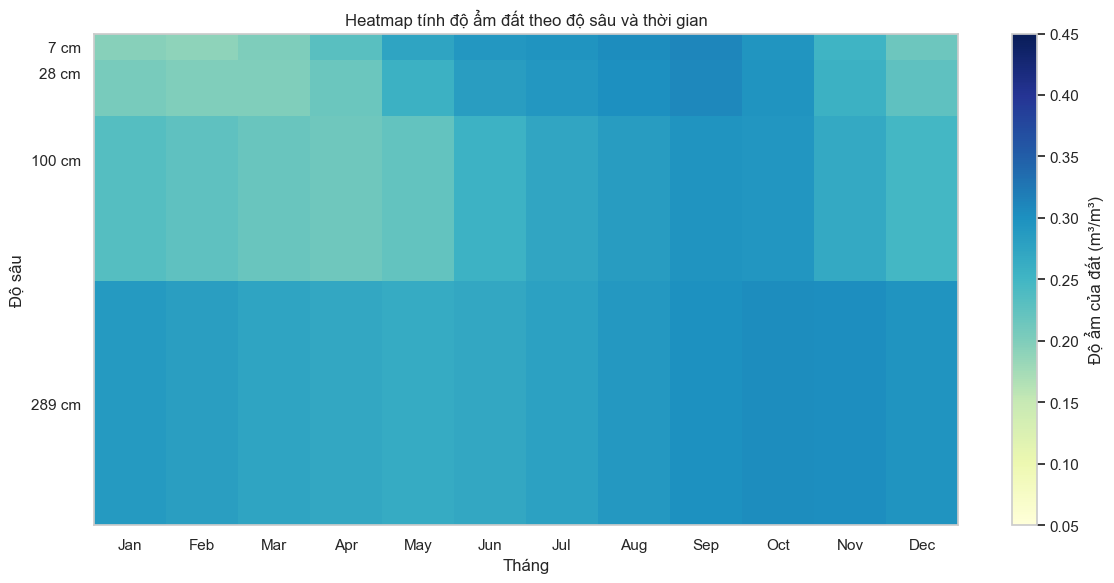

In [11]:
# 45-year climatology: df_clim is already indexed by month (1–12)
clim_vals = df_clim[sw_vars].loc[range(0, 12)].values.T  # shape: 4 × 12

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

fig_all, ax_all = plt.subplots(figsize=(12, 6))

c = ax_all.pcolormesh(range(1, 13), depths, clim_vals,
                      cmap="YlGnBu", vmin=0.05, vmax=0.45, shading="auto")
ax_all.set_xticks(range(1, 13))
ax_all.set_xticklabels(month_labels)
ax_all.set_yticks(depths)
ax_all.set_yticklabels(depth_lbls)
ax_all.invert_yaxis()
ax_all.set_xlabel("Tháng")
ax_all.set_ylabel("Độ sâu")
ax_all.set_title("Heatmap tính độ ẩm đất theo độ sâu và thời gian")
plt.colorbar(c, ax=ax_all, label="Độ ẩm của đất (m³/m³)")
plt.tight_layout()
plt.show()

## 3. Tổng lượng nước trung bình trong đất qua các năm

Biểu đồ này tính tổng lượng nước trong tất cả 4 tầng đất, tính trung bình qua từng năm và xuyên suốt 45 năm. Ta thấy rõ trong biểu đồ sự biến động rõ rệt giữa các năm theo xu hướng biến thiên tăng dần. Và đồng thời từ đó ta cũng có thể kết luận được rằng về dài hạn, đất có xu hướng bị khô hạn.

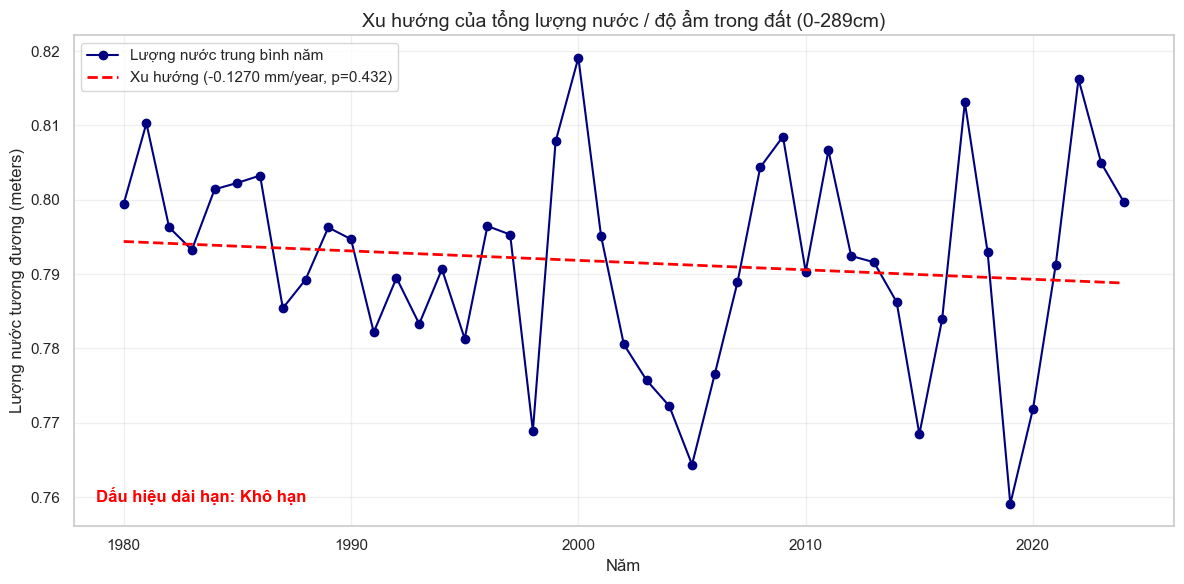

In [12]:
# Ensure time is datetime format
df_daily['time'] = pd.to_datetime(df_daily['time'])

# Define ERA5 layer thicknesses (in meters)
d1, d2, d3, d4 = 0.07, 0.21, 0.72, 1.89

# Calculate the thickness-weighted column integral (daily_col)
# Resulting unit: meters of water
df_daily['daily_col'] = (df_daily['swvl1'] * d1 + 
                         df_daily['swvl2'] * d2 + 
                         df_daily['swvl3'] * d3 + 
                         df_daily['swvl4'] * d4)

# Resample to Annual Mean
df_annual = df_daily.resample('YE', on='time')['daily_col'].mean().reset_index()
df_annual['year'] = df_annual['time'].dt.year

# Calculate Linear Trend
slope, intercept, r_value, p_value, std_err = linregress(df_annual['year'], df_annual['daily_col'])
df_annual['trend'] = intercept + slope * df_annual['year']

plt.figure(figsize=(12, 6))
plt.plot(df_annual['year'], df_annual['daily_col'], marker='o', linestyle='-', color='navy', label='Lượng nước trung bình năm')
plt.plot(df_annual['year'], df_annual['trend'], color='red', linestyle='--', linewidth=2, 
         label=f'Xu hướng ({slope*1000:.4f} mm/year, p={p_value:.3f})')

plt.title('Xu hướng của tổng lượng nước / độ ẩm trong đất (0-289cm)', fontsize=14)
plt.ylabel('Lượng nước tương đương (meters)', fontsize=12)
plt.xlabel('Năm', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

# Highlight drying or wetting
if slope < 0:
    plt.text(0.02, 0.05, "Dấu hiệu dài hạn: Khô hạn", color='red', transform=plt.gca().transAxes, fontweight='bold')
else:
    plt.text(0.02, 0.05, "Dấu hiệu dài hạn: Uớt", color='blue', transform=plt.gca().transAxes, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Heatmap đo dị thường trong độ ẩm đất theo từng tầng, trong từng năm, tháng

Từ heatmap này ta có thể xem dị thường của từng tầng đất một, để xem trong suốt các năm tháng lượng độ ẩm trong đất có biến đổi gì bất thường hay không.

Ta thấy rõ rằng càng đi sâu xuống dưới tầng đất thì biến động bất thường (dị thường) càng ngày càng ít đi, nhường chỗ cho sự ổn định hơn.

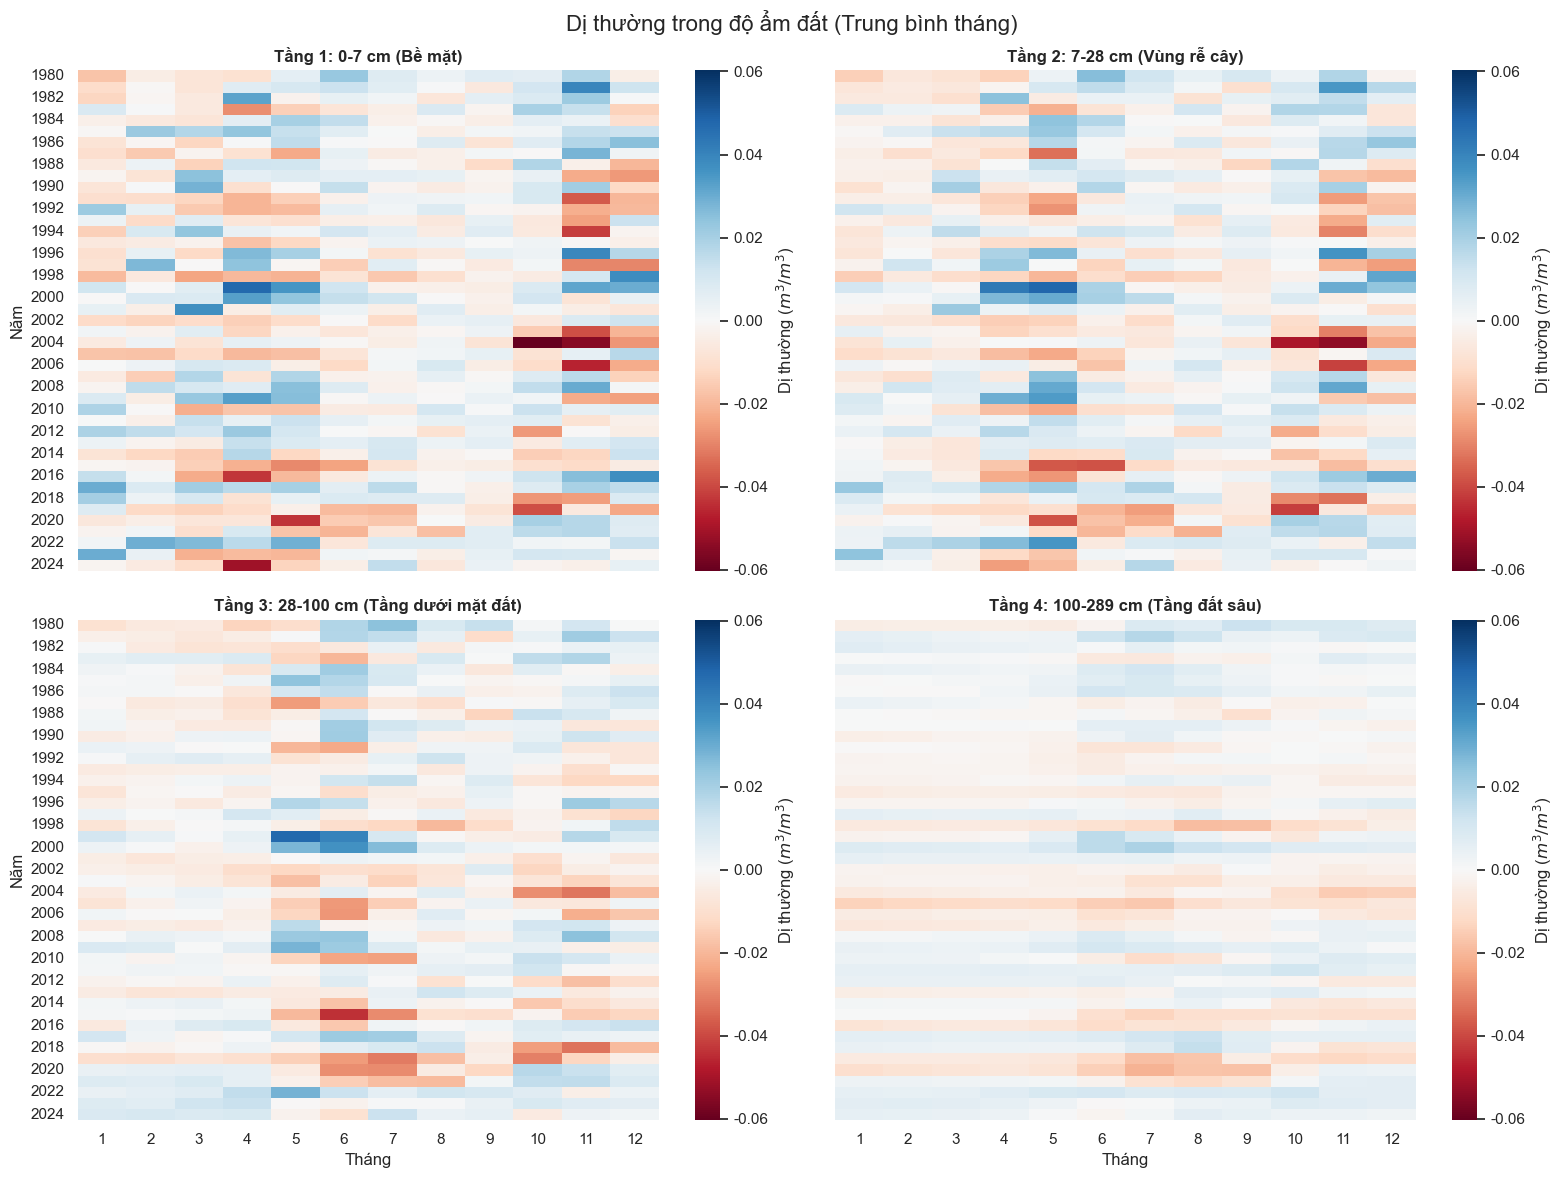

In [13]:
# Ensure time is datetime
df_anom['time'] = pd.to_datetime(df_anom['time'])

# Aggregate daily anomalies to Monthly Means first
df_anom_monthly = df_anom.resample('MS', on='time').mean().reset_index()

# Extract year and month from the aggregated data
df_anom_monthly['year'] = df_anom_monthly['time'].dt.year
df_anom_monthly['month'] = df_anom_monthly['time'].dt.month

# Determine global color scale limits for consistency
layers = ['swvl1', 'swvl2', 'swvl3', 'swvl4']
max_anom = df_anom_monthly[layers].abs().max().max()
v_min, v_max = -max_anom, max_anom

# Setup the 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

titles = [
    'Tầng 1: 0-7 cm (Bề mặt)',
    'Tầng 2: 7-28 cm (Vùng rễ cây)',
    'Tầng 3: 28-100 cm (Tầng dưới mặt đất)',
    'Tầng 4: 100-289 cm (Tầng đất sâu)'
]

for i, layer in enumerate(layers):
    # Pivot the aggregated monthly data
    pivot_table = df_anom_monthly.pivot(index='year', columns='month', values=layer)
    
    # Create heatmap
    sns.heatmap(pivot_table, 
                ax=axes[i], 
                cmap='RdBu',     # Red = Dry, Blue = Wet
                center=0, 
                vmin=v_min, 
                vmax=v_max, 
                cbar_kws={'label': 'Dị thường ($m^3/m^3$)'})
    
    axes[i].set_title(titles[i], fontweight='bold')
    axes[i].set_ylabel('Năm' if i % 2 == 0 else '')
    axes[i].set_xlabel('Tháng' if i >= 2 else '')

plt.suptitle('Dị thường trong độ ẩm đất (Trung bình tháng)', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

## 5. Độ trễ lan truyền ẩm giữa các tầng đất

Từ biểu đồ, ta thấy được rằng thời gian để lan truyền độ ẩm giữa các tầng đất sẽ tăng dần từ tầng bề mặt xuống các tầng sâu hơn. Hệ số tương quan Pearson càng cao, thì có nghĩa là biến động giữa 2 tầng đất càng giống nhau, nước truyền xuống nhanh hơn.

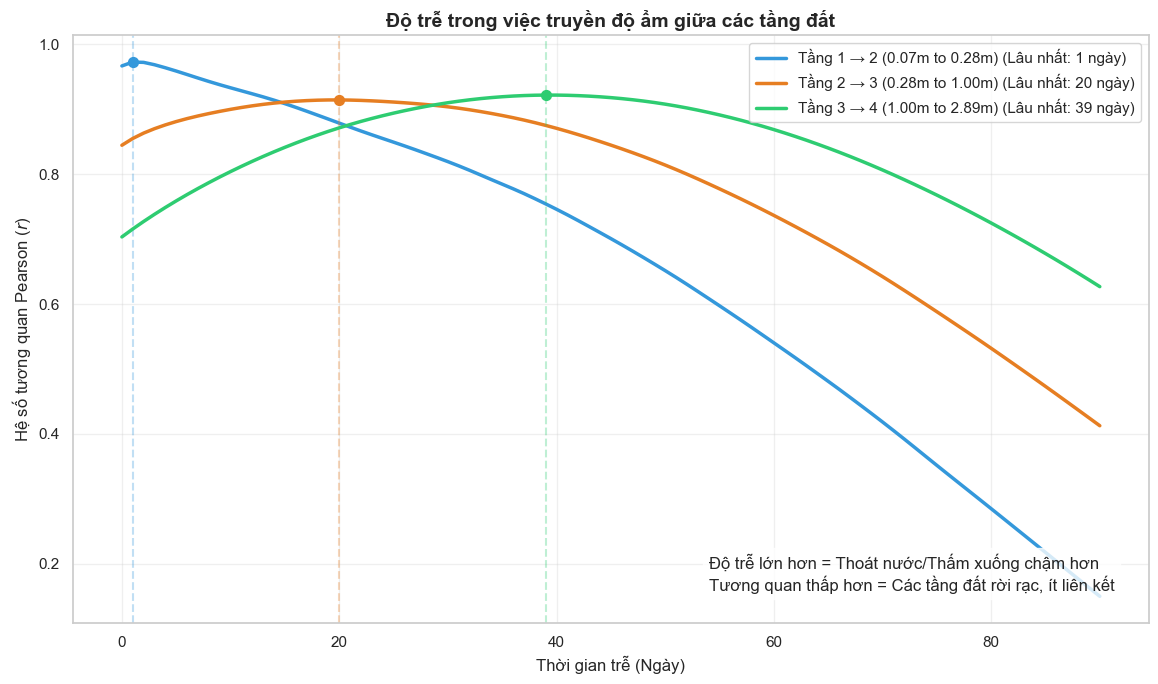

In [14]:
# Define the pairs and the lag range
pairs = [('swvl1', 'swvl2'), ('swvl2', 'swvl3'), ('swvl3', 'swvl4')]
labels = ['Tầng 1 → 2 (0.07m to 0.28m)', 
          'Tầng 2 → 3 (0.28m to 1.00m)', 
          'Tầng 3 → 4 (1.00m to 2.89m)']
max_lag = 90
lags = range(max_lag + 1)

# Calculate Cross-Correlation for each pair
correlation_results = {pair: [] for pair in pairs}

for p1, p2 in pairs:
    for lag in lags:
        # We correlate shallow layer (t) with deep layer (t + lag)
        # .shift(-lag) moves future values to the current row
        c = df_daily[p1].corr(df_daily[p2].shift(-lag))
        correlation_results[(p1, p2)].append(c)

plt.figure(figsize=(12, 7))
colors = ['#3498db', '#e67e22', '#2ecc71']

for i, (pair, color) in enumerate(zip(pairs, colors)):
    series = correlation_results[pair]
    peak_lag = series.index(max(series))
    peak_val = max(series)
    
    plt.plot(lags, series, label=f'{labels[i]} (Lâu nhất: {peak_lag} ngày)', 
             color=color, linewidth=2.5)
    
    # Mark the peak with a dot and vertical line
    plt.axvline(x=peak_lag, color=color, linestyle='--', alpha=0.3)
    plt.scatter(peak_lag, peak_val, color=color, s=50, zorder=5)

plt.title('Độ trễ trong việc truyền độ ẩm giữa các tầng đất', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian trễ (Ngày)', fontsize=12)
plt.ylabel('Hệ số tương quan Pearson ($r$)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='best', frameon=True)

# Add interpretation text
plt.text(max_lag*0.6, plt.ylim()[0] + 0.05, 
         "Độ trễ lớn hơn = Thoát nước/Thấm xuống chậm hơn\nTương quan thấp hơn = Các tầng đất rời rạc, ít liên kết",
         bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

## 6. Chỉ số độ ẩm đất chuẩn hoá (SSI)

Làm phép trừ giữa trung bình tháng và chia cho độ lệch chuẩn, ta có được độ ẩm đất chuẩn hoá. Màu đỏ thể hiện sự khô hạn, còn màu xanh thể hiện đất ẩm ướt. Biểu đồ này thể hiện rõ ràng cho các năm.

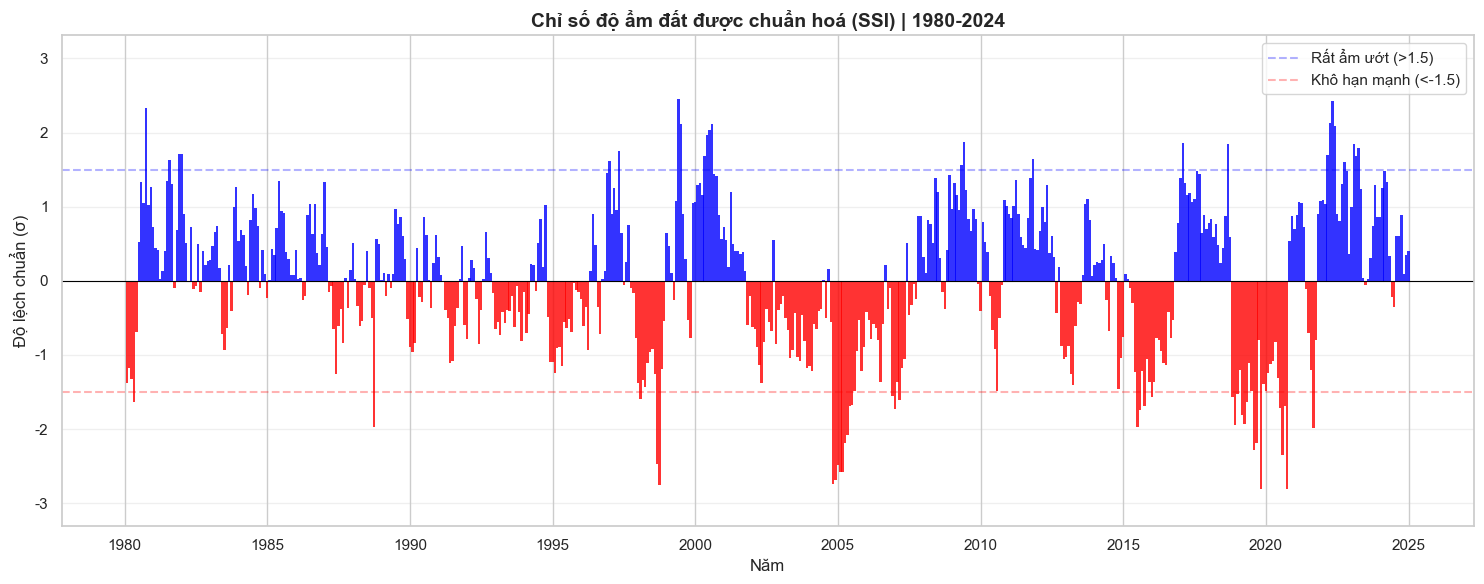

In [15]:
weights = [0.07, 0.21, 0.72, 1.89]
df_monthly['col_sm'] = (df_monthly['swvl1'] * weights[0] + 
                        df_monthly['swvl2'] * weights[1] + 
                        df_monthly['swvl3'] * weights[2] + 
                        df_monthly['swvl4'] * weights[3])

# Compute Long-term Monthly Mean and Std Dev (Climatology)
# We group by month (1-12) to ensure we compare Jan with Jan, Feb with Feb, etc.
df_monthly['month'] = pd.to_datetime(df_monthly['time']).dt.month
climatology = df_monthly.groupby('month')['col_sm'].agg(['mean', 'std']).reset_index()
climatology.columns = ['month', 'climatology_mean', 'climatology_std']

# Merge climatology back to the monthly dataframe
df_ssi = pd.merge(df_monthly, climatology, on='month')

# Calculate the SSI (Standardized Soil-moisture Index)
# SSI = (Value - Mean) / StdDev
df_ssi['ssi'] = (df_ssi['col_sm'] - df_ssi['climatology_mean']) / df_ssi['climatology_std']

# Sort by time to ensure the plot is chronological
df_ssi = df_ssi.sort_values('time')

plt.figure(figsize=(15, 6))

# Create colors: Red for negative (drought), Blue for positive (wet)
colors = ['red' if x < 0 else 'blue' for x in df_ssi['ssi']]

plt.bar(df_ssi['time'], df_ssi['ssi'], color=colors, width=31, edgecolor='none', alpha=0.8)

# Add styling and reference lines
plt.axhline(0, color='black', linewidth=0.8)
plt.axhline(1.5, color='blue', linestyle='--', alpha=0.3, label='Rất ẩm ướt (>1.5)')
plt.axhline(-1.5, color='red', linestyle='--', alpha=0.3, label='Khô hạn mạnh (<-1.5)')

plt.title('Chỉ số độ ẩm đất được chuẩn hoá (SSI) | 1980-2024', fontsize=14, fontweight='bold')
plt.ylabel('Độ lệch chuẩn (σ)', fontsize=12)
plt.xlabel('Năm', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper right')

# Set y-limits to make the plot symmetrical
limit = max(abs(df_ssi['ssi'].min()), abs(df_ssi['ssi'].max())) + 0.5
plt.ylim(-limit, limit)

plt.tight_layout()
plt.show()

In [16]:
output_dir = r'D:\GitHub\climate-analysis-and-prediction\data\soil_moisture'
os.makedirs(output_dir, exist_ok=True)

df_daily.to_parquet(f"{output_dir}/daily.parquet", compression='snappy')
df_monthly.to_parquet(f"{output_dir}/monthly.parquet", compression='snappy')
df_clim.to_parquet(f"{output_dir}/climatology.parquet", compression='snappy')
df_anom.to_parquet(f"{output_dir}/anomaly.parquet", compression='snappy')

print("✅ Saved soil moisture (all parquet)")

✅ Saved soil moisture (all parquet)
